# Project C — RAG benchmark analysis

Compares **single_shot** vs **multi_step** retrieval over TPI Carbon Performance reports (TNB, DEWA, CenterPoint), across two models (Qwen3-30B, Qwen3-235B), on 6 questions = 24 runs.

Input: `logs/runs.jsonl`. Figures saved to `docs/images/`. This notebook is the evidence layer behind the report; each section maps to a claim the report makes.

## 1. Load and derive fields

Parses scores into numerator/denominator, derives the verdict tag, distinct-companies-retrieved (for the coverage analysis), and stable `Q1`–`Q6` labels. Asserts guard against a drifted dump.

In [23]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Find repo root by walking up from cwd, so this works whether the notebook is
# launched from repo root or from inside evaluation/. Anchored on logs/runs.jsonl.
ROOT = Path.cwd()
while not (ROOT / "logs" / "runs.jsonl").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:  # so we can reuse the faithfulness chunk loader (section 7)
    sys.path.insert(0, str(ROOT))

RUNS_PATH = ROOT / "logs" / "runs.jsonl"
FIG_DIR = ROOT / "docs" / "images"
FIG_DIR.mkdir(parents=True, exist_ok=True)

rows = [json.loads(l) for l in RUNS_PATH.open(encoding="utf-8")]
df = pd.DataFrame(rows)


def parse_frac(s):
    """'3/5' -> (3, 5); None/'' -> (None, None). Never averages across questions."""
    if not s or "/" not in str(s):
        return (None, None)
    n, d = str(s).split("/")
    return (int(n), int(d))


def verdict(note):
    """Cross-question aggregation tag, from the first word of the note."""
    w = str(note).strip().lower()
    if w.startswith("correct"):
        return "correct"
    if w.startswith("wrong"):
        return "wrong"
    if w.startswith("abstain"):
        return "abstained"
    return "unknown"


def short_model(m):
    return "235B" if "235" in str(m) else "30B"


def companies_retrieved(labels):
    """Distinct companies whose documents reached the prompt, from document labels."""
    s = set()
    for L in labels or []:
        L = str(L)
        if L.startswith("TNB"):
            s.add("TNB")
        elif L.startswith("DEWA"):
            s.add("DEWA")
        elif "enter" in L.lower() and "point" in L.lower():
            s.add("CenterPoint")
    return s


df["model_s"] = df["model"].map(short_model)
df["verdict"] = df["evaluator_notes"].map(verdict)
df[["corr_n", "corr_d"]] = df["correctness"].apply(lambda s: pd.Series(parse_frac(s)))
df[["faith_n", "faith_d"]] = df["faithfulness_score"].apply(lambda s: pd.Series(parse_frac(s)))
df["corr_prop"] = df["corr_n"] / df["corr_d"]  # WITHIN-question proportion only
df["n_companies"] = df["selected_document_labels"].map(lambda x: len(companies_retrieved(x)))

_order = df.groupby("question_id")["run_id"].min().sort_values()
QLABEL = {qid: f"Q{i + 1}" for i, qid in enumerate(_order.index)}
df["Q"] = df["question_id"].map(QLABEL)

assert len(df) == 24, f"expected 24 runs, got {len(df)}"
assert df["verdict"].ne("unknown").all(), "unparsed verdict tag in evaluator_notes"
assert df[["corr_n", "faith_n"]].notna().all().all(), "null score — a run is unscored"

# Shared style.
PIPE_C = {"single_shot": "#c44", "multi_step": "#28a"}
CONFIGS = [
    ("single_shot", "30B"),
    ("single_shot", "235B"),
    ("multi_step", "30B"),
    ("multi_step", "235B"),
]

legend = (
    df[["Q", "question"]]
    .drop_duplicates()
    .sort_values("Q")
    .assign(question=lambda d: d["question"].str.slice(0, 90) + "…")
    .set_index("Q")
)
legend

,question
Q,
Q1,Comparing Tenaga Nasional and DEWA's emissions...
Q2,Given each company's most recent reported emis...
Q3,Has Tenaga set intermediate emissions reductio...
Q4,Has DEWA’s carbon emission intensity for elect...
Q5,What has changed in each company's stated emis...
Q6,"For each of the three companies, compare the a..."


## 2. Per-question correctness

One panel per question; bars annotated with the raw fraction, denominator in the title. Compare bars **within** a panel — never average across panels (denominators differ). The near-identical 30B/235B pairs make the *model size barely matters* finding visible; multi_step (blue) weakly dominates single_shot (red) — better on Q1/Q4/Q5, tied where corpus corruption zeroes both.

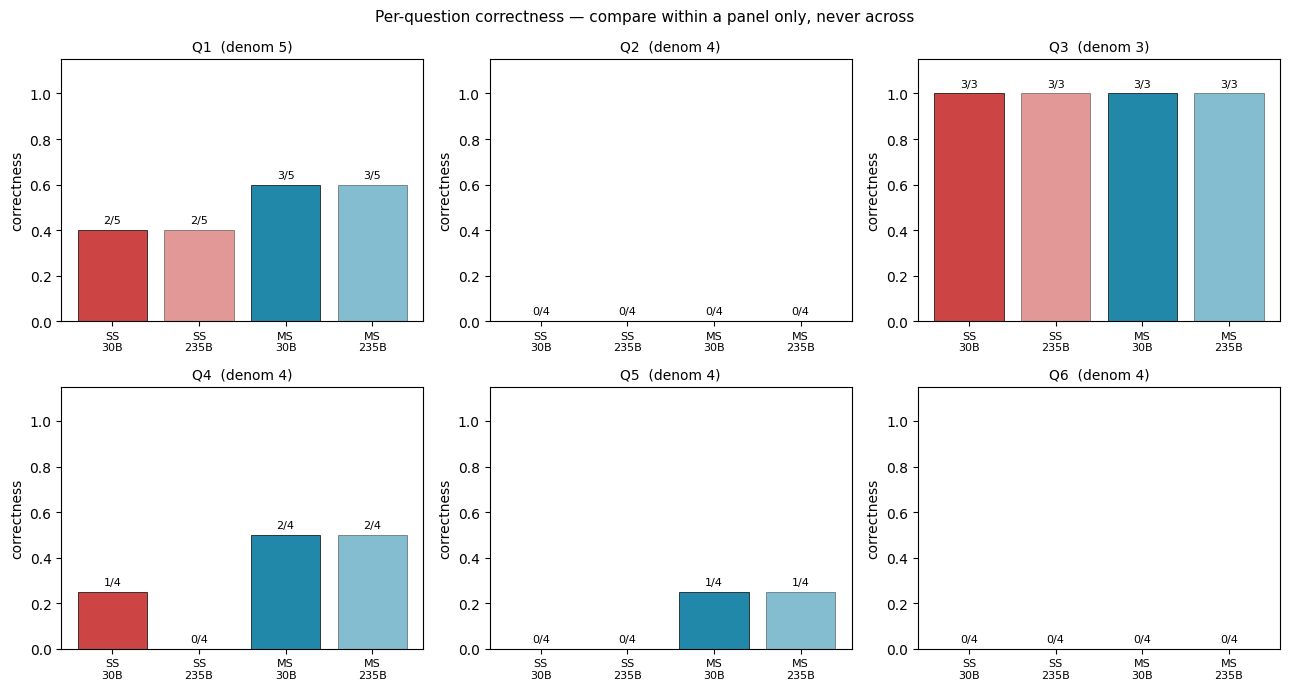

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, q in zip(axes, sorted(df["Q"].unique())):
    sub = df[df["Q"] == q]
    den = int(sub["corr_d"].iloc[0])
    vals, labs = [], []
    for p, m in CONFIGS:
        r = sub[(sub["pipeline_type"] == p) & (sub["model_s"] == m)]
        vals.append(r["corr_prop"].iloc[0] if len(r) else 0)
        labs.append(r["correctness"].iloc[0] if len(r) else "-")
    bars = ax.bar(
        range(len(CONFIGS)),
        vals,
        color=[PIPE_C[p] for p, _ in CONFIGS],
        edgecolor="black",
        linewidth=0.5,
    )
    for b, (_, m) in zip(bars, CONFIGS):
        if m == "235B":
            b.set_alpha(0.55)  # lighter shade = larger model, within each pipeline colour
    for x, v, l in zip(range(len(CONFIGS)), vals, labs):
        ax.text(x, v + 0.03, l, ha="center", fontsize=8)
    ax.set_xticks(range(len(CONFIGS)))
    ax.set_xticklabels(["SS\n30B", "SS\n235B", "MS\n30B", "MS\n235B"], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{q}  (denom {den})", fontsize=10)
    ax.set_ylabel("correctness")
fig.suptitle("Per-question correctness — compare within a panel only, never across", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "correctness_by_question.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Verdict composition

The headline trustworthiness view. single_shot abstains on 5/12 runs vs multi_step's 2/12; decomposition converts abstentions into answers — yielding both more *correct* and more *wrong*. Split by model confirms size barely shifts the mix.

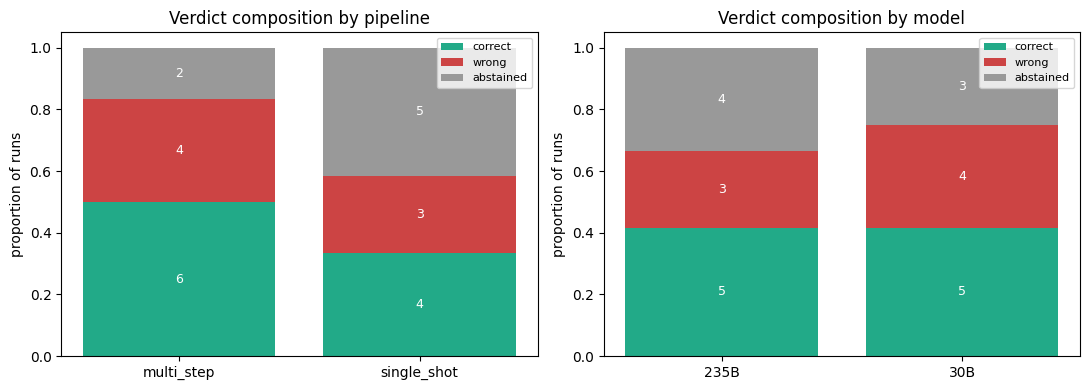

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
VC = {"correct": "#2a8", "wrong": "#c44", "abstained": "#999"}
for ax, (dim, title) in zip(axes, [("pipeline_type", "by pipeline"), ("model_s", "by model")]):
    ct = pd.crosstab(df[dim], df["verdict"])[["correct", "wrong", "abstained"]]
    ctp = ct.div(ct.sum(axis=1), axis=0)
    bottom = [0] * len(ctp)
    for v in ["correct", "wrong", "abstained"]:
        ax.bar(ctp.index, ctp[v], bottom=bottom, color=VC[v], label=v)
        for i, idx in enumerate(ctp.index):
            if ctp[v].iloc[i] > 0.04:
                ax.text(
                    i,
                    bottom[i] + ctp[v].iloc[i] / 2,
                    f"{ct[v].iloc[i]}",
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=9,
                )
        bottom = [bottom[i] + ctp[v].iloc[i] for i in range(len(ctp))]
    ax.set_title(f"Verdict composition {title}")
    ax.set_ylabel("proportion of runs")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "verdict_composition.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Retrieval coverage — the failure mechanism

Where each pipeline fails, measured. single_shot's abstentions all occur at **exactly one** company retrieved — it abstains because it under-retrieves. multi_step's failures (wrong or abstained) occur at **full three-company** coverage — so its failures are downstream reasoning, not retrieval. The two pipelines fail in different components, and it is measurable.

Honest caveat: this cleanly explains single_shot's *abstentions*; its *wrong* answers are mixed (on Q5 it retrieved all three companies and was still wrong).

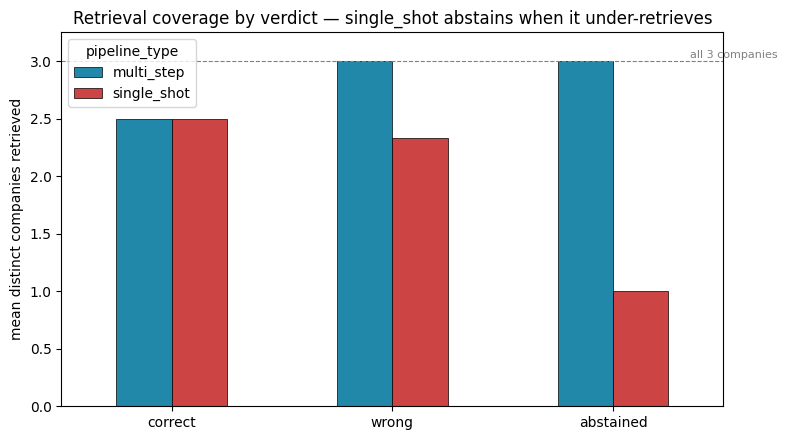

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
piv = df.pivot_table(
    index="verdict", columns="pipeline_type", values="n_companies", aggfunc="mean"
).reindex(["correct", "wrong", "abstained"])
piv.plot(
    kind="bar", ax=ax, color=[PIPE_C[c] for c in piv.columns], edgecolor="black", linewidth=0.5
)
ax.axhline(3, ls="--", c="gray", lw=0.8)
ax.text(2.35, 3.03, "all 3 companies", fontsize=8, color="gray")
ax.set_ylim(0, 3.25)
ax.set_ylabel("mean distinct companies retrieved")
ax.set_xlabel("")
ax.set_title("Retrieval coverage by verdict — single_shot abstains when it under-retrieves")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "retrieval_coverage.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Cost, latency, tokens

The price of decomposition. Each panel titles the multi/single multiplier — the trustworthiness gain above comes at a large compute cost.

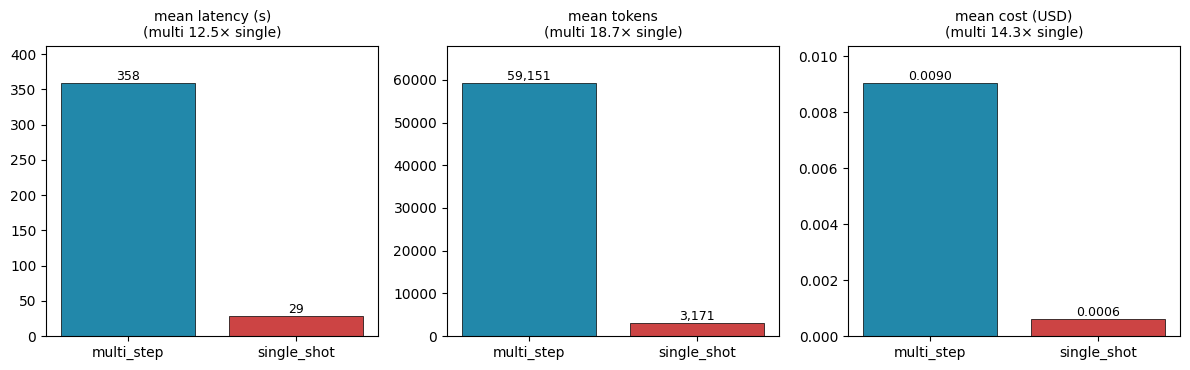

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
panels = [
    ("latency_seconds", "mean latency (s)", "{:,.0f}"),
    ("total_tokens", "mean tokens", "{:,.0f}"),
    ("total_cost_usd", "mean cost (USD)", "{:,.4f}"),
]
for ax, (col, lab, fmt) in zip(axes, panels):
    g = df.groupby("pipeline_type")[col].mean()
    ax.bar(g.index, g.values, color=[PIPE_C[p] for p in g.index], edgecolor="black", linewidth=0.5)
    for i, v in enumerate(g.values):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=9)
    r = g["multi_step"] / g["single_shot"]
    ax.set_title(f"{lab}\n(multi {r:.1f}× single)", fontsize=10)
    ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "cost_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Faithfulness

Pooled faithfulness (supported claims / total claims; corpus-error counts as faithful). Uniformly high (93–96%) and similar across pipelines — single_shot is marginally higher, while multi_step makes *more* claims at near-identical faithfulness. The pipeline difference is **not** fabrication; the few sub-100% runs assert from absence rather than invent facts.

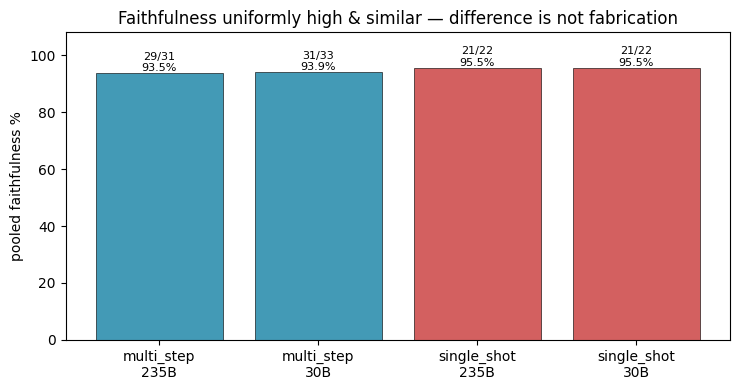

In [28]:
fig, ax = plt.subplots(figsize=(7.5, 4))
g = df.groupby(["pipeline_type", "model_s"]).agg(
    supported=("faith_n", "sum"), total=("faith_d", "sum")
)
g["pct"] = 100 * g["supported"] / g["total"]
labels = [f"{p}\n{m}" for p, m in g.index]
ax.bar(
    labels,
    g["pct"],
    color=[PIPE_C[p] for p, _ in g.index],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
)
for i, (_, row) in enumerate(g.iterrows()):
    ax.text(
        i,
        row["pct"],
        f"{int(row['supported'])}/{int(row['total'])}\n{row['pct']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_ylim(0, 108)
ax.set_ylabel("pooled faithfulness %")
ax.set_title("Faithfulness uniformly high & similar — difference is not fabrication")
fig.tight_layout()
fig.savefig(FIG_DIR / "faithfulness.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Inspectability cases

Two failures shown beside the retrieved chunk that should have prevented them; chunk text is resolved live from `data/chunked/` so the evidence is the real retrieved text.

- **Run 57** — claimed DEWA improved *consistently*; its own chunk shows the 2021 reversal.
- **Run 53** — called TNB *credible* by reading a 5% **target** as achieved trajectory.

In [29]:
from evaluation.make_faithfulness_sheet import load_chunk_text

chunk_text = load_chunk_text()

SPOTLIGHT = {
    57: {
        "chunk_id": "DEWA_2021_chunk_0448",
        "failure": (
            "Claimed DEWA intensity 'improved consistently since 2010', but its own "
            "retrieved chunk shows 2019->2020->2021 = 0.4818->0.4744->0.4834 - a RISE in "
            "2021. Pure reasoning failure: the contradicting figure was in the prompt."
        ),
    },
    53: {
        "chunk_id": "TNB_2024_chunk_0421",
        "failure": (
            "Concluded 'TNB credible' because its 5% annual reduction exceeds the 3.33% "
            "required. But the chunk states the 5% is a TARGET 'from 2024' onward - a "
            "projected trajectory, not the achieved reduction the question asked for. "
            "Faithful to the text, wrong reasoning (treated a target as an outcome)."
        ),
    },
}

runs_by_id = df.set_index("run_id")
for rid, spot in SPOTLIGHT.items():
    r = runs_by_id.loc[rid]
    print(
        f"RUN {rid} - {r['pipeline_type']} {r['model_s']} | "
        f"correctness {r['correctness']} | faithfulness {r['faithfulness_score']} "
        f"| verdict: {r['verdict']}"
    )
    print("-" * 60)
    print("QUESTION:", r["question"])
    print("\nMODEL ANSWER:\n", r["answer"])
    cid = spot["chunk_id"]
    print("\nCONTRADICTING RETRIEVED CHUNK -", cid, ":\n", chunk_text.get(cid, "not found"))
    print("\nFAILURE TRACE:", spot["failure"])
    print()

RUN 57 - single_shot 30B | correctness 1/4 | faithfulness 2/3 | verdict: wrong
------------------------------------------------------------
QUESTION: Has DEWA’s carbon emission intensity for electricity (reported in tCO₂e/MWh) improved consistently since 2010, and what was the net reduction from 2010 to 2024?

MODEL ANSWER:
 DEWA’s carbon emission intensity for electricity has improved consistently since 2010, based on the available data.

From the retrieved passages:
- In 2010, the carbon emission intensity for electricity was 0.538 tCO₂e/MWh (DEWA Sustainability Report 2016, p.68).
- In 2023, the carbon emission intensity for electricity was 0.3979 tCO₂e/MWh (DEWA Sustainability Report 2023, p.56).
- The 2024 data is not available in the retrieved passages, so the net reduction from 2010 to 2024 cannot be calculated.

However, the reduction from 2010 to 2023 can be calculated as follows:
- 2010 intensity: 0.538 tCO₂e/MWh
- 2023 intensity: 0.3979 tCO₂e/MWh
- Reduction = 0.538 – 0.3979

## 8. Findings and limitations

The cell below recomputes the headline numbers so the prose that follows is reproducible, not transcribed.

In [30]:
vc = pd.crosstab(df["pipeline_type"], df["verdict"])[["correct", "wrong", "abstained"]]
fa = df.groupby("pipeline_type").agg(fn=("faith_n", "sum"), fd=("faith_d", "sum"))
fa["pct"] = (100 * fa["fn"] / fa["fd"]).round(1)
co = df.groupby("pipeline_type").agg(
    lat=("latency_seconds", "mean"), tok=("total_tokens", "mean"), cost=("total_cost_usd", "mean")
)
mult = (co.loc["multi_step"] / co.loc["single_shot"]).round(1)

print("Verdicts by pipeline:\n", vc.to_string(), "\n")
print("Pooled faithfulness %:\n", fa["pct"].to_string(), "\n")
print(
    "multi/single multipliers — latency {lat}x, tokens {tok}x, cost {cost}x".format(
        lat=mult["lat"], tok=mult["tok"], cost=mult["cost"]
    )
)
print("\nPer-question correctness (multi never below single):")
print(
    df.pivot_table(index="Q", columns="pipeline_type", values="corr_prop", aggfunc="max")
    .round(2)
    .to_string()
)


# Corpus-corruption evidence behind finding 4: which runs flag corruption, and the
# per-question correctness that results (Q5 = most flagged = lowest non-zero score).
def _corpus_flag(n):
    n = str(n).lower()
    return any(k in n for k in ["corpus", "garble", "corrupt", "damaged"])


df["corpus_note"] = df["evaluator_notes"].map(_corpus_flag)
print("\nRuns flagging corpus corruption:")
print(
    df.loc[df["corpus_note"], ["run_id", "Q", "pipeline_type", "model_s", "correctness"]].to_string(
        index=False
    )
)
print("\nMean correctness by question (corruption concentrates on Q5):")
print(df.assign(prop=df["corr_n"] / df["corr_d"]).groupby("Q")["prop"].mean().round(2).to_string())

Verdicts by pipeline:
 verdict        correct  wrong  abstained
pipeline_type                           
multi_step           6      4          2
single_shot          4      3          5 

Pooled faithfulness %:
 pipeline_type
multi_step     93.8
single_shot    95.5 

multi/single multipliers — latency 12.5x, tokens 18.7x, cost 14.3x

Per-question correctness (multi never below single):
pipeline_type  multi_step  single_shot
Q                                     
Q1                   0.60         0.40
Q2                   0.00         0.00
Q3                   1.00         1.00
Q4                   0.50         0.25
Q5                   0.25         0.00
Q6                   0.00         0.00

Runs flagging corpus corruption:
 run_id  Q pipeline_type model_s correctness
     36 Q1    multi_step     30B         3/5
     40 Q5    multi_step     30B         1/4
     48 Q1    multi_step    235B         3/5
     58 Q5   single_shot     30B         0/4
     64 Q5   single_shot    235B       

### What the evidence supports

1. **multi_step outperforms single_shot on correctness.** It weakly dominates per question — better on Q1, Q4, Q5; tied elsewhere; never worse — and records 6 correct vs 4 with far fewer abstentions (2 vs 5). The gain is modest, not dramatic: where corpus corruption zeroes a question, both pipelines fail equally.

2. **Faithfulness is similar; the real difference is correctness/coverage.** All four configurations sit at 93–96% pooled faithfulness (single_shot marginally higher). multi_step makes *more* claims at the same faithfulness rate, i.e. it is more substantive without fabricating more. So multi_step's advantage is in retrieving and using the right evidence, not in being more truthful to the text.

3. **That advantage costs compute.** multi_step runs ~12–13× slower, uses ~19× the tokens, and costs ~14× as much (section 5). The recommendation is a trustworthiness-for-cost trade, and there are clear drawbacks.

4. **Extraction quality is a measurable drag on correctness.** Five runs — across Q1 and Q5 — carry explicit corpus-corruption notes (a 345% figure where 35% was meant, TNB intensity garbled by ~50%, corrupted 2019 endpoints). The effect shows up in the scores: Q5, the most corruption-flagged question, collapses to 0.12 mean correctness while staying faithful to the (corrupted) text. Better extraction would most directly help these cases. Note the honest boundary: Q2 and Q6 score zero for *all* configurations with no corruption flags, so those failures are not attributable to extraction — they are hard multi-part questions. It is likely that TPI Centre will greatly benefit from integrating the findings from this project along with those from Project A and B, as we resorted to unstructured and passing tables to Gemini for better extraction. This integration is forward-looking and not substantiated by the current results.

### Limitations

- **Small sample.** 6 questions × 2 pipelines × 2 models. All numbers are descriptive; no significance testing is claimed or warranted.
- **Single-rater scoring.** Correctness and faithfulness were scored by one evaluator.
- **Correctness is not averaged across questions** — denominators differ per question, so fractions are only compared within a question (section 2). Cross-question aggregation uses the verdict tag instead.
- **Corpus corruption caps numeric correctness** for every configuration, as above.